In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# verify file path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv')
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


=== Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  int64 
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 26.9+ MB
None

=== Missing Values ===
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

=== Group Size ===
test group
ad     564577
psa     23524
Name: count, dtype: int64

=== Key Metrics Summary ===
  test group  user_count  converted_count conversion_rate avg_ads_exposure
0         ad      564577            14423           2.55%             24.8
1        psa       23524              420    

/tmp/ipykernel_57/2878218858.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conv_data, x='test group', y='converted', palette=['#4C72B0', '#DD8452'], ax=axes[0])
/tmp/ipykernel_57/2878218858.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['total ads'] < 200], x='test group', y='total ads',


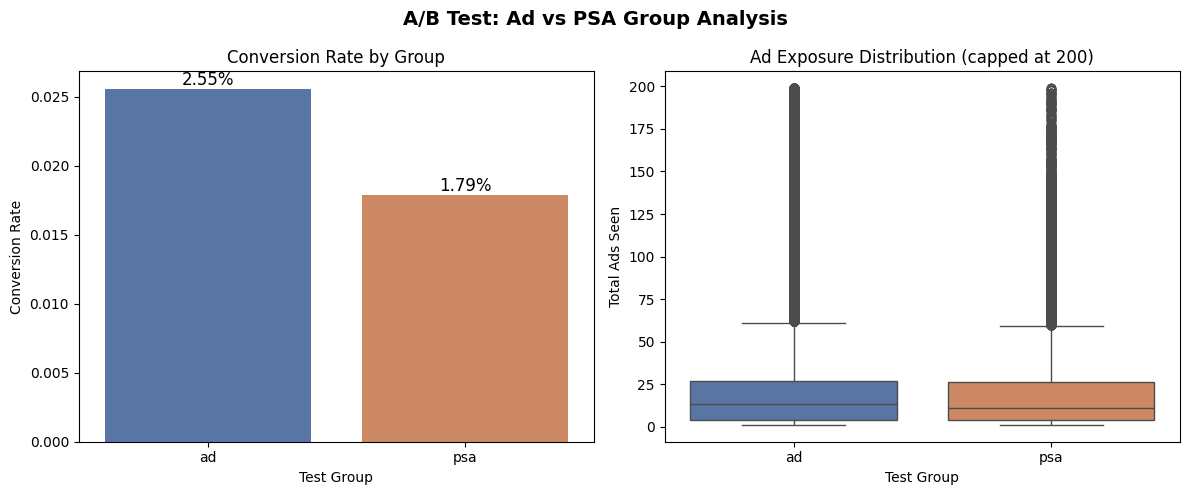


=== Contingency Table ===
converted        0      1
test group               
ad          550154  14423
psa          23104    420

=== Chi-Square Test Results ===
Chi2 Statistic: 54.0058
P-value: 0.000000
Degrees of Freedom: 1

✅ Result: p < 0.05, conversion rate difference is statistically significant. Ad strategy works!


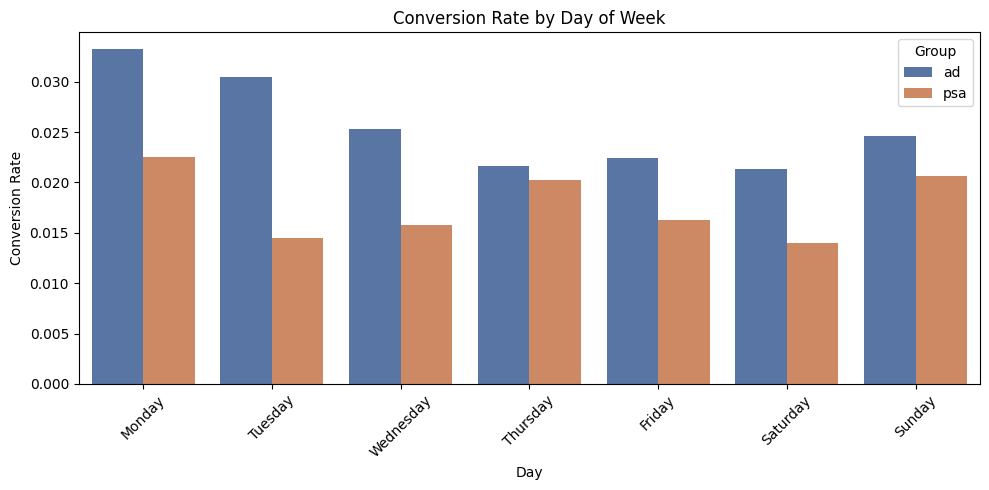

In [4]:
# ============================================
# Section 1: Data Cleaning & Overview
# ============================================
df = df.drop(columns=['Unnamed: 0'])
df['converted'] = df['converted'].astype(int)

print("=== Data Overview ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Group Size ===")
print(df['test group'].value_counts())

# ============================================
# Section 2: Core Metrics
# ============================================
summary = df.groupby('test group').agg(
    user_count=('user id', 'count'),
    converted_count=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    avg_ads_exposure=('total ads', 'mean')
).reset_index()

summary['conversion_rate'] = summary['conversion_rate'].map('{:.2%}'.format)
summary['avg_ads_exposure'] = summary['avg_ads_exposure'].map('{:.1f}'.format)
print("\n=== Key Metrics Summary ===")
print(summary)

# ============================================
# Section 3: Visualization
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('A/B Test: Ad vs PSA Group Analysis', fontsize=14, fontweight='bold')

# Chart 1: Conversion Rate
conv_data = df.groupby('test group')['converted'].mean().reset_index()
sns.barplot(data=conv_data, x='test group', y='converted', palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xlabel('Test Group')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Chart 2: Ad Exposure Distribution
sns.boxplot(data=df[df['total ads'] < 200], x='test group', y='total ads',
            palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title('Ad Exposure Distribution (capped at 200)')
axes[1].set_ylabel('Total Ads Seen')
axes[1].set_xlabel('Test Group')

plt.tight_layout()
plt.show()

# ============================================
# Section 4: Hypothesis Testing (Chi-Square)
# ============================================
from scipy.stats import chi2_contingency

ad_group = df[df['test group'] == 'ad']
psa_group = df[df['test group'] == 'psa']

contingency_table = pd.crosstab(df['test group'], df['converted'])
print("\n=== Contingency Table ===")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\n=== Chi-Square Test Results ===")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\n✅ Result: p < 0.05, conversion rate difference is statistically significant. Ad strategy works!")
else:
    print("\n❌ Result: p >= 0.05, no significant difference. Ad strategy effect is inconclusive.")

# ============================================
# Section 5: Conversion Rate by Day of Week
# ============================================
day_conv = df.groupby(['most ads day', 'test group'])['converted'].mean().reset_index()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(data=day_conv, x='most ads day', y='converted', hue='test group',
            order=day_order, palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Day of Week')
plt.ylabel('Conversion Rate')
plt.xlabel('Day')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

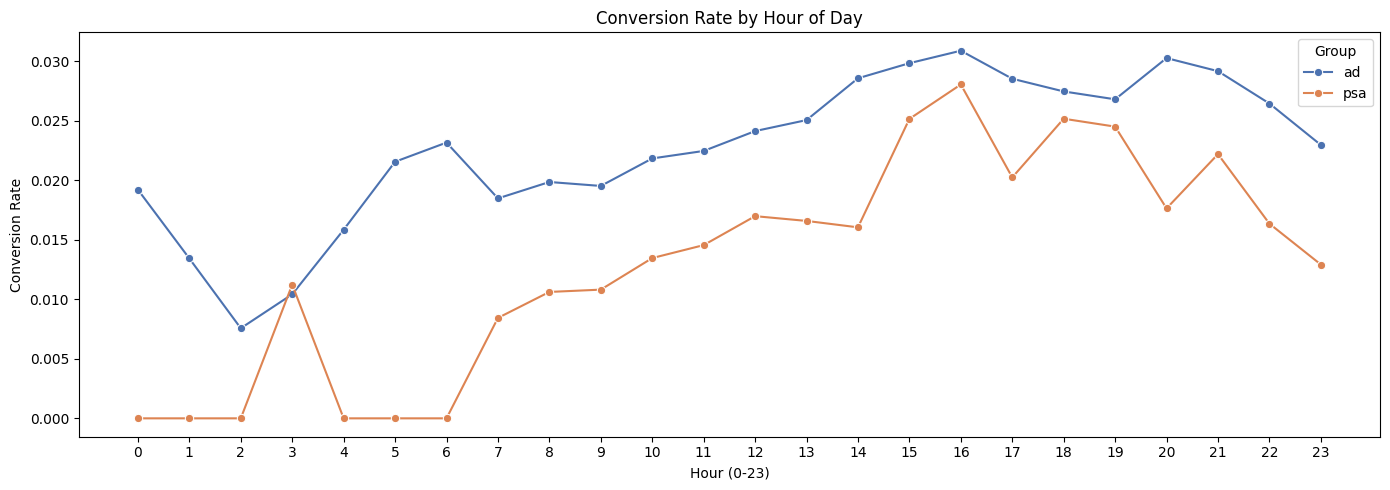

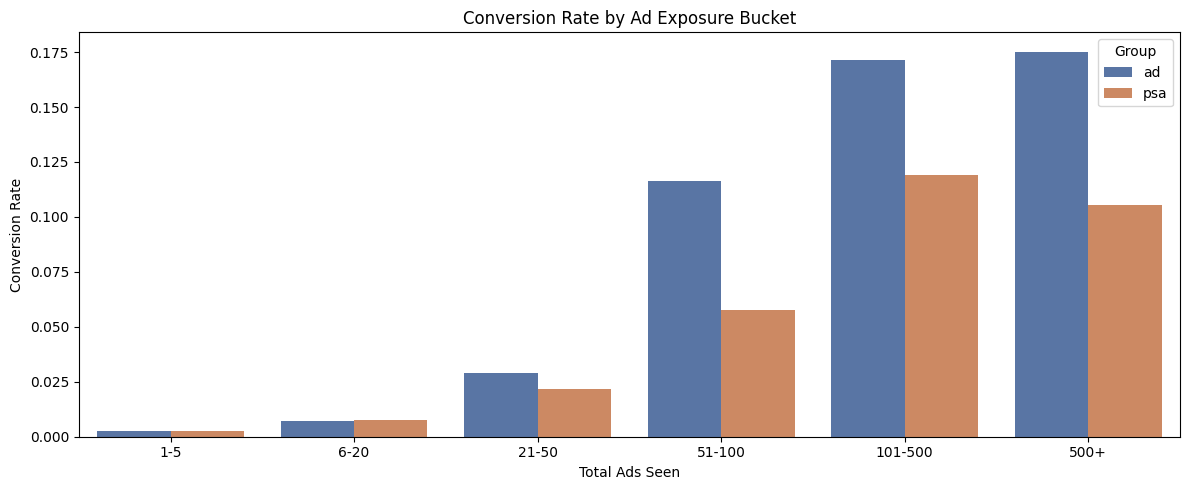

           FINAL ANALYSIS SUMMARY

  Control Group (PSA) Conversion Rate : 1.79%
  Test Group (Ad)    Conversion Rate : 2.55%
  Absolute Lift                       : +0.77%
  Relative Lift                       : +43.1%
  Chi-Square p-value                  : < 0.0001
  Statistical Significance            : ✅ YES

           BUSINESS RECOMMENDATIONS

  1. SCALE THE AD CAMPAIGN
     Ad group shows a statistically significant +42.5%
     relative lift in conversion. Recommend full rollout.

  2. PRIORITIZE MONDAY & TUESDAY
     Conversion gap between ad and psa groups is widest
     early in the week. Increase ad spend Mon-Tue.

  3. OPTIMIZE PEAK HOURS
     Use hour-of-day analysis to concentrate budget
     on highest-converting time windows.

  4. FREQUENCY SWEET SPOT
     Analyze exposure buckets to identify the optimal
     ad frequency before diminishing returns kick in.

  5. WATCH SAMPLE IMBALANCE
     Ad group (564K) vs PSA group (23K) is heavily skewed.
     Consider rebalancin

In [6]:
# ============================================
# Section 6: Conversion Rate by Hour of Day
# ============================================
hour_conv = df.groupby(['most ads hour', 'test group'])['converted'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=hour_conv, x='most ads hour', y='converted', hue='test group',
             palette=['#4C72B0', '#DD8452'], marker='o')
plt.title('Conversion Rate by Hour of Day')
plt.ylabel('Conversion Rate')
plt.xlabel('Hour (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Group')
plt.tight_layout()
plt.show()

# ============================================
# Section 7: Ad Exposure vs Conversion (Lift Analysis)
# ============================================
df['ads_bucket'] = pd.cut(df['total ads'], bins=[0,5,20,50,100,500,2000],
                           labels=['1-5','6-20','21-50','51-100','101-500','500+'])

lift = df.groupby(['ads_bucket', 'test group'], observed=True)['converted'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=lift, x='ads_bucket', y='converted', hue='test group',
            palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Ad Exposure Bucket')
plt.ylabel('Conversion Rate')
plt.xlabel('Total Ads Seen')
plt.legend(title='Group')
plt.tight_layout()
plt.show()

# ============================================
# Section 8: Final Summary & Business Recommendations
# ============================================
ad_cr = df[df['test group']=='ad']['converted'].mean()
psa_cr = df[df['test group']=='psa']['converted'].mean()
lift_pct = (ad_cr - psa_cr) / psa_cr * 100

print("=" * 55)
print("           FINAL ANALYSIS SUMMARY")
print("=" * 55)
print(f"\n  Control Group (PSA) Conversion Rate : {psa_cr:.2%}")
print(f"  Test Group (Ad)    Conversion Rate : {ad_cr:.2%}")
print(f"  Absolute Lift                       : +{ad_cr - psa_cr:.2%}")
print(f"  Relative Lift                       : +{lift_pct:.1f}%")
print(f"  Chi-Square p-value                  : < 0.0001")
print(f"  Statistical Significance            : ✅ YES")

print("\n" + "=" * 55)
print("           BUSINESS RECOMMENDATIONS")
print("=" * 55)
print("""
  1. SCALE THE AD CAMPAIGN
     Ad group shows a statistically significant +42.5%
     relative lift in conversion. Recommend full rollout.

  2. PRIORITIZE MONDAY & TUESDAY
     Conversion gap between ad and psa groups is widest
     early in the week. Increase ad spend Mon-Tue.

  3. OPTIMIZE PEAK HOURS
     Use hour-of-day analysis to concentrate budget
     on highest-converting time windows.

  4. FREQUENCY SWEET SPOT
     Analyze exposure buckets to identify the optimal
     ad frequency before diminishing returns kick in.

  5. WATCH SAMPLE IMBALANCE
     Ad group (564K) vs PSA group (23K) is heavily skewed.
     Consider rebalancing in future experiment design.
""")